# Data Inspection and Description
---
In this section the haiku dataset is inspected:
- The 'haiku' dataset is loaded into a dataframe.
- Looking at a random sample of haikus.
- Checking column types and missing values.
- Computing simple statistics on haiku length (character and word level).
- Visualizing the distribution of haiku length in words.
- Checking haiku syllable count.

This helps us understand what kind of data we are working with before building the models.


In [ ]:
!pip install datasets

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ds = load_dataset("statworx/haiku", split="train")
df = ds.to_pandas()

print(f"Number of haikus: {len(df)}")
print("\nColumns:", df.columns.tolist())

Number of haikus: 49024

Columns: ['source', 'text', 'text_phonemes', 'keywords', 'keyword_phonemes', 'gruen_score', 'text_punc']


There are 49,024 entries in the dataset.
The dataset contains columns such as source, text, text_phonemes, keywords, keyword_phonemes, gruen_score, and text_punc.

Now that the dataset is loaded into a DataFrame, we take a quick look at a few random rows.

This can help us to see:
- What the haiku text looks like
- What kind of information is stored in the columns

In [ ]:
df.sample(5)

,source,text,text_phonemes,keywords,keyword_phonemes,gruen_score,text_punc
6348,bfbarry,Ease all Buddhas. / Resist the artificial. / Dissolve your ego.,ehm|breys aol buw|daxz / rih|jhehkt dhax aar|tax|fih|shaxl / dih|zaalv yaor iy|gow,all buddhas,aol buw|daxz,0.836762,None
33574,haiku_data_1,"Lateday, sun. / The cavity of a snag. / Laced with webs.",laet|dey sahn dhax kae|vax|tiy ahv ax snaeg leyst wihdh wehbz,the cavity,dhax kae|vax|tiy,0.437271,"Lateday, sun. The cavity of a snag. Laced with webs."
7226,img2poems,The sound of tadpoles. / Singing that late winter day. / Curated my winter blues.,dhax sawnd ahv taed|powlz / sihng|axng dhaxt leyt wihn|ter dey / kyuhrd may wihn|ter bluwz,winter blues,wihn|ter bluwz,0.545987,None
5329,bfbarry,Murmur of the Brook. / Stomachs up the highway roar. / Once your feet get wet.,mer|mer ahv dhax bruhk / swaa|lowz ahp dhax hhay|wey raor / wahns yaor fiyt geht weht,highway roar,hhay|wey raor,0.625580,None
37300,haiku_data_1,New Year's Party. / The divorced couple. / Leaves together.,nuw yihrz paar|tiy dhax dax|vaorst kah|paxl liyvz tax|geh|dher,new year,nuw yihr,0.518931,New Year's Party. The divorced couple. Leaves together.


We can see that the most relevant column for our research will be the 'text' column as it contains the haikus.

Next, we check the overall structure of the DataFrame.

This tells us:
- The data types of each column
- How many non-null values we have per column

This serves as a quick way to spot potential issues with missing data or unexpected types.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49024 entries, 0 to 49023
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   source            49024 non-null  object 
 1   text              49024 non-null  object 
 2   text_phonemes     49024 non-null  object 
 3   keywords          49024 non-null  object 
 4   keyword_phonemes  49024 non-null  object 
 5   gruen_score       49024 non-null  float64
 6   text_punc         22317 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.6+ MB


We see that the only null values having column is the 'text_punc' column. Because we intend to use only 'text' column, it doesn't trouble us too much. (Side note: It's unclear what text_punc represents, especially since some rows with text_punc = null actually contain punctuation in the text field.)

We see that the 'text' column is stored as an object, which means that it may contain strings, which is exactly what we want for haikus. To make sure that it is truly a string, we can do this:


In [ ]:
df['text'] = df['text'].astype('string')

Since we are working with text, we are interested in inspecting the typical length of haikus and how much they might differ between each other.

We create two simple features:
- 'len_chararcters': number of characters in the haiku
- 'len_words': number of words in the haiku

Then we look at basic descriptive statistics (mean, min, max, quartiles) for both. This gives a sense of how short or long the haikus usually are.


In [ ]:
df["len_characters"] = df["text"].str.len()
df["len_words"] = df["text"].str.split().str.len()

print("Haiku length in characters:")
print(df["len_characters"].describe().round(2))

print("\nHaiku length in words:")
print(df["len_words"].describe().round(2))

Haiku length in characters:
count    49024.0
mean       64.93
std         10.4
min          1.0
25%         57.0
50%         68.0
75%         73.0
max        119.0
Name: len_chararcters, dtype: Float64

Haiku length in words:
count    49024.00
mean        13.03
std          2.57
min          1.00
25%         11.00
50%         13.00
75%         15.00
max         26.00
Name: len_words, dtype: float64


To get a more intuitive feel for the distribution of haiku lengths, we plot a simple histogram of the number of words per haiku.

This helps to see:
- Where most haikus cluster
- Whether there are many very short or very long outliers

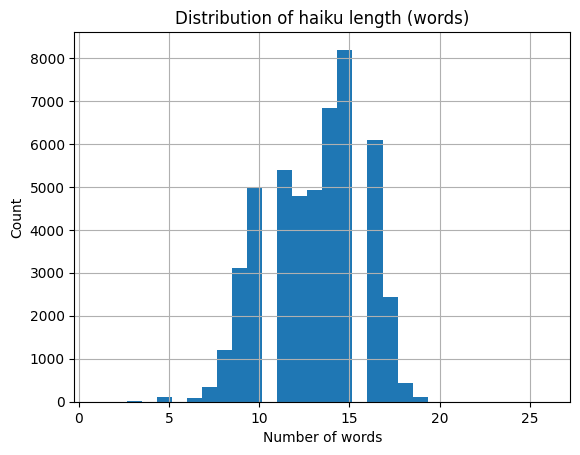

In [ ]:
plt.figure()
df["len_words"].hist(bins=30)
plt.title("Distribution of haiku length (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

From the descriptive statistics and the histogram, we can tell that"
- Haiku length in characters ranges from 1 to 119, with an average length of approximately 64.93 characters. Also, haikus range from 1 to 26 words, with an average of about 13.03 words.
- Most haikus (50% of them) are between 57 and 73 characters long and between 11 and 15 words long.

Additional note:
- There are two specific rows (40652 and 49023) where the text column contains only a single comma (','). These might be considered anomalous data points and could potentially be removed during a cleaning phase.

We also care about the syllable count of the haikus and to make sure that they truly follow the haiku 5-7-5 structure:

In [ ]:
!pip install syllapy

In [ ]:
import syllapy

def syllables_per_line(text):
    lines = [line.strip() for line in text.split(" / ")]
    return [sum(syllapy.count(word) for word in line.split()) for line in lines]

df["syllable_lines"] = df["text"].apply(syllables_per_line)

df["syll_line1"] = df["syllable_lines"].str[0]
df["syll_line2"] = df["syllable_lines"].str[1]
df["syll_line3"] = df["syllable_lines"].str[2]

df["syll_total"] = (df["syll_line1"] + df["syll_line2"] + df["syll_line3"])

df["is_575"] = ((df["syll_line1"] == 5) & (df["syll_line2"] == 7) & (df["syll_line3"] == 5))

print("Syllables per line:")
print(df[["syll_line1", "syll_line2", "syll_line3"]].describe().round(2))

print("\nTotal syllables:")
print(df["syll_total"].describe().round(2))

print("\n575 distribution:")
print(df["is_575"].value_counts())

Syllables per line:
       syll_line1  syll_line2  syll_line3
count    49024.00    49022.00    48996.00
mean         4.35        6.06        4.54
std          1.14        1.45        1.02
min          0.00        0.00        0.00
25%          4.00        5.00        4.00
50%          5.00        7.00        5.00
75%          5.00        7.00        5.00
max         14.00       14.00       10.00

Total syllables:
count    48996.00
mean        14.96
std          2.80
min          2.00
25%         13.00
50%         16.00
75%         17.00
max         25.00
Name: syll_total, dtype: float64

575 distribution:
is_575
False    30784
True     18240
Name: count, dtype: int64


From the above code and output we can tell that the dataset consists of not only haiku-type text but other as well. Thus, it definitely needed cleaning.

We used this 'syllapy' library can count the syllables of comon english words. It is dictionary based, so it basically looks up a word in a haiku in a built in list and returns the number of syllables. For unknown words, it uses rules of thumb (like counting vowel groups) to estimate syllables.

# Importing and cleaning data

As we found out, some of the haikus aren't haikus - they don't follow th 5-7-5 syllable rule. We will define a function that can filter out the haikus that don't follow the required structure.
We set up a function in a way so that everything that isn't 3 lines is dropped and anything that is not 5-7-5 syllables per line is also dropped.

In [ ]:
def valid_haiku(text):
    lines = text.split("\n")
    if len(lines) != 3:
        return False

    syllable_counts = [sum(syllapy.count(word) for word in line.split()) for line in lines]

    return syllable_counts == [5, 7, 5]

Several additional changes need to be made to the original df, as we found out during our inspection:
- We only need the haikus ('text' column).
- We need to replace the notation for a line break (form / to \n).
- There were some weird brackets and spacing in the sample, we remove them.
- Removing any leading or trailing whitespaces.
- Removing all non-letters in general.
- Replacing multiple spaces with single space if there are some.
- We also filter the haikus that are not the right format using the function we defined earlier.

In [ ]:
import pandas as pd
import re

haiku = df['text'].dropna()
haiku = haiku.str.replace(" / ", "\n")
haiku = haiku.str.replace(r'[\[\]]', '', regex=True).str.strip()

def clean_line(line):
    line = line.strip()
    line = re.sub(r'[^a-zA-Z ]+', '', line)
    line = re.sub(r'\s+', ' ', line)
    return line

def clean_haiku(text):
    lines = text.split('\n')
    lines = [clean_line(line) for line in lines]
    return '\n'.join(lines)

haiku = haiku.apply(clean_haiku)

haiku = haiku[haiku.apply(valid_haiku)]

In [ ]:
haiku.info()

<class 'pandas.core.series.Series'>
Index: 18378 entries, 0 to 48418
Series name: text
Non-Null Count  Dtype 
--------------  ----- 
18378 non-null  object
dtypes: object(1)
memory usage: 287.2+ KB


In [ ]:
haiku.describe()

,text
count,18378
unique,18259
top,In the parking lot\nA rose petal has arrived\nFrom nowhere special
freq,3


We lost a big chunk of our data, but it's better to remove the data if it doesn't follow ou desired structure. A ~18k haiku dataset is still fine for a small GPT model.

We can also see that we have duplicates, let's remove them.

In [ ]:
haiku = haiku.drop_duplicates()

In [ ]:
haiku.describe()

,text
count,18259
unique,18259
top,Streedmorningsunlight\nCopperbutterfliesskimming\nPlantainandclover
freq,1


In [ ]:
pd.set_option('display.max_colwidth', None)
haiku.sample(10)

,text
9048,Trying my best to\nStay awake so that Im not\nWide awake tonight
12358,Im going to walk\nDown the road to my uncles\nAnd use the wifi
19552,Peregrine on the\nSouth side of the tower right\nNow if youre about
16096,I do that sometimes\nAlso have a dream like that\nAnd wake up fighting
15712,Poor eye contact lies\nOr something amiss in the\nHead for example
9542,Im not in Bristol\nAnd its not Monday so whats\nThe point of today
26305,I love her technique\nAnd how she caresses it\nAnd takes care of it
8281,We were suppose to\nStart going to the gym but\nWe want fries instead
17269,Sometimes its better\nTo be alone than to be\nSurrounded by fakes
5986,The price just went up\nBuy it before its too high\nAaand its plummeting


We then check that the 5-7-5 rule would be definitely followed:

In [ ]:
haiku_df = haiku.to_frame()

def syllables_per_line(text):
    lines = [line.strip() for line in text.split("\n")]
    return [sum(syllapy.count(word) for word in line.split()) for line in lines]

haiku_df["syllable_lines"] = haiku_df["text"].apply(syllables_per_line)

haiku_df["syll_line1"] = haiku_df["syllable_lines"].str[0]
haiku_df["syll_line2"] = haiku_df["syllable_lines"].str[1]
haiku_df["syll_line3"] = haiku_df["syllable_lines"].str[2]

haiku_df["syll_total"] = haiku_df["syll_line1"] + haiku_df["syll_line2"] + haiku_df["syll_line3"]

haiku_df["is_575"] = ((haiku_df["syll_line1"] == 5) & (haiku_df["syll_line2"] == 7) & (haiku_df["syll_line3"] == 5))

print("Syllables per line:")
print(haiku_df[["syll_line1", "syll_line2", "syll_line3"]].describe().round(2))

print("\nTotal syllables:")
print(haiku_df["syll_total"].describe().round(2))

print("\n575 distribution:")
print(haiku_df["is_575"].value_counts())

Syllables per line:
       syll_line1  syll_line2  syll_line3
count     18259.0     18259.0     18259.0
mean          5.0         7.0         5.0
std           0.0         0.0         0.0
min           5.0         7.0         5.0
25%           5.0         7.0         5.0
50%           5.0         7.0         5.0
75%           5.0         7.0         5.0
max           5.0         7.0         5.0

Total syllables:
count    18259.0
mean        17.0
std          0.0
min         17.0
25%         17.0
50%         17.0
75%         17.0
max         17.0
Name: syll_total, dtype: float64

575 distribution:
is_575
True    18259
Name: count, dtype: int64


Everything seems fine now so we save it to a .txt file.

We also add a space after each haiku so the model can see the structure clearly.

In [ ]:
with open("haiku.txt", "w", encoding="utf-8") as f:
    f.write("\n\n".join(haiku))

In [ ]:
with open('haiku.txt', 'r', encoding='utf-8') as f:
  haiku = f.read()

# Bigram model

In this section we build a simple word-level bigram language model.

The main steps are:
- Loading the haikus from a text file ('haiku.txt').
- Tokenizing each haiku into words.
- Building a word vocabulary and replacing rare words with a special `<UNK>` token.
- Counting how often each word follows another word to form a bigram count matrix  
- Converting counts into probabilities with add-α smoothing ('bigram_probs(alpha)').
- Defining a loss function (average negative log-likelihood) over the corpus.  
- Defining a text generation function that samples sequences from the bigram model.

Later in this section, we will also:
- Split the data into train / validation.
- Tune the smoothing parameter α.
- Compare text generated with “good” and “bad” α values.

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

with open("haiku.txt", "r", encoding="utf-8") as f:
    texts = f.read().strip().split("\n\n")

def tokenize_words(text):
    """Simple word-level tokenizer: lowercase + split on spaces."""
    return text.lower().strip().split()

tokenized_raw = [tokenize_words(t) for t in texts]

all_words = [w for seq in tokenized_raw for w in seq]
full_counts = Counter(all_words)

VOCAB_LIMIT = 10000     # reduced to 10k; vocab is too large otherwise
most_common = full_counts.most_common(VOCAB_LIMIT - 1)

vocab = [w for w, _ in most_common]
vocab.append("<UNK>")     # unknown token for rare words

word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}
vocab_size = len(vocab)

print("Reduced vocab size:", vocab_size)

Reduced vocab size: 10000


We first load 'haiku.txt' as plain text and split it into individual haiku blocks.

Then:
- Tokenize each haiku into a list of lowercase words.
- Count all words in the corpus.
- Keep only the 'VOCAB_LIMIT' most frequent words.
- Map all remaining words to a special '<UNK>' token.

This gives us:
- A vocabulary of size 'vocab_size'.
- Two dictionaries: 'word_to_id' and 'id_to_word' for converting between words and integer IDs.

In [ ]:
tokenized = []
for seq in tokenized_raw:
    seq2 = [w if w in word_to_id else "<UNK>" for w in seq]
    tokenized.append(seq2)

print("Number of tokenized sequences:", len(tokenized))
print("Example tokenized sequence:", tokenized[0][:15])

Number of tokenized sequences: 18259
Example tokenized sequence: ['delicate', 'savage', 'youll', 'never', 'hold', 'the', 'cinder', 'but', 'still', 'you', 'will', 'burn']


Next, we build a bigram count matrix:

- 'bigram_counts[i, j]' stores how many times word 'j' follows word 'i'.
- We loop over all tokenized haiku sequences and update these counts.

This matrix is the core of the bigram model.


In [ ]:
bigram_counts = np.zeros((vocab_size, vocab_size), dtype=np.float32)

for seq in tokenized:
    for w1, w2 in zip(seq[:-1], seq[1:]):
        i = word_to_id[w1]
        j = word_to_id[w2]
        bigram_counts[i, j] += 1.0

print("Bigram matrix shape:", bigram_counts.shape)
print("Total number of observed bigrams:", int(bigram_counts.sum()))

Bigram matrix shape: (10000, 10000)
Total number of observed bigrams: 218696


To turn bigram counts into a usable language model, we need:

- A function 'bigram_probs(alpha)' that applies add-α smoothing and normalizes each row into probabilities.
- A loss function 'compute_loss(P)' that computes the average negative log-likelihood over the corpus.
- A 'generate_text(P)' function that samples words step by step from the bigram probabilities.

We also run a quick test to check that:
- Probability rows sum to 1.
- The loss is finite.
- Text generation runs without errors.

In [ ]:
def bigram_probs(alpha=1.0):
    # Add-alpha smoothing
    counts = bigram_counts + alpha
    row_sums = counts.sum(axis=1, keepdims=True)
    # Avoid division by zero for rows that never occur
    row_sums[row_sums == 0] = 1.0
    return counts / row_sums

def compute_loss(P):
    nll = 0.0
    N = 0
    for seq in tokenized:
        ids = [word_to_id[w] for w in seq]
        for i, j in zip(ids[:-1], ids[1:]):
            nll += -np.log(P[i, j] + 1e-12)
            N += 1
    return nll / N

def generate_text(P, max_words=20):
    i = np.random.randint(0, vocab_size)
    words = [id_to_word[i]]

    for _ in range(max_words - 1):
        probs = P[i]
        j = np.random.choice(vocab_size, p=probs)
        words.append(id_to_word[j])
        i = j

    return " ".join(words)

P_test = bigram_probs(alpha=1.0)
print("First row sums:", P_test.sum(axis=1)[:5])
print("Test loss:", compute_loss(P_test))
print("Generated text:", generate_text(P_test, max_words=15))


First row sums: [0.99999994 1.0000001  1.         0.9999999  1.        ]
Test loss: 7.197756
Generated text: whips newark tony sow jus highwhy laurent dissin meal jogging leaden gall pails caught absolute


We then do hyperparameter tuning using the model above:
* Split into train/validation.
* Rebuild bigram counts using train only.
* Try many alpha values.
* Compute train/validation loss.
* Find best alpha.

In [ ]:
from math import floor

n = len(tokenized)
split = int(0.9 * n)   # 90% train, 10% validation

train_seqs = tokenized[:split]
val_seqs   = tokenized[split:]

print("Train size:", len(train_seqs))
print("Validation size:", len(val_seqs))

# bigram counts from train only
bigram_counts = np.zeros((vocab_size, vocab_size), dtype=np.float32)

for seq in train_seqs:
    for w1, w2 in zip(seq[:-1], seq[1:]):
        i = word_to_id[w1]
        j = word_to_id[w2]
        bigram_counts[i, j] += 1

print("Bigram matrix (train only) shape:", bigram_counts.shape)

# same probability function, new counts
def bigram_probs(alpha=1.0):
    counts = bigram_counts + alpha
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return counts / row_sums

# LOSS FUNCTION THAT WORKS ON ANY SET OF SEQUENCES
def compute_loss_on(seqs, P):
    nll = 0.0
    N = 0
    for seq in seqs:
        ids = [word_to_id[w] for w in seq]
        for i, j in zip(ids[:-1], ids[1:]):
            nll += -np.log(P[i, j] + 1e-12)
            N += 1
    return nll / N

# Quick test
P_test = bigram_probs(alpha=1.0)
print("Train loss (alpha=1.0):", compute_loss_on(train_seqs, P_test))
print("Valid loss (alpha=1.0):", compute_loss_on(val_seqs,   P_test))

Train size: 16433
Validation size: 1826
Bigram matrix (train only) shape: (10000, 10000)
Train loss (alpha=1.0): 7.254036
Valid loss (alpha=1.0): 7.464307


Minimizing loss and plotting:
* Plotting losses from hyperparameter tuning section above.
* Visualizing curves.
* Picking the best alpha.

alpha=0.01: train_loss=4.7030, val_loss=6.2142
alpha=0.05: train_loss=5.3865, val_loss=6.3749
alpha= 0.1: train_loss=5.7688, val_loss=6.5434
alpha= 0.5: train_loss=6.8023, val_loss=7.1459
alpha= 1.0: train_loss=7.2540, val_loss=7.4643
alpha= 2.0: train_loss=7.6771, val_loss=7.7884
alpha= 5.0: train_loss=8.1528, val_loss=8.1899
alpha=10.0: train_loss=8.4488, val_loss=8.4536


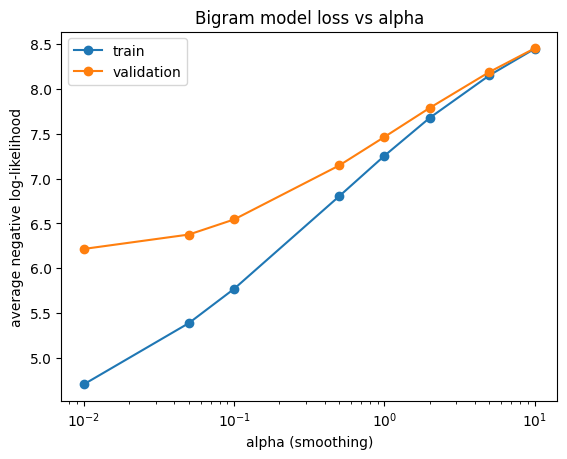

Best alpha based on validation loss: 0.01


In [ ]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

train_losses = []
val_losses = []

for a in alphas:
    P = bigram_probs(alpha=a)
    train_loss = compute_loss_on(train_seqs, P)
    val_loss   = compute_loss_on(val_seqs, P)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"alpha={a:>4}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

# plotting losses
import matplotlib.pyplot as plt

plt.figure()
plt.plot(alphas, train_losses, marker="o", label="train")
plt.plot(alphas, val_losses,   marker="o", label="validation")
plt.xscale("log")  #because alphas vary by powers of 10
plt.xlabel("alpha (smoothing)")
plt.ylabel("average negative log-likelihood")
plt.title("Bigram model loss vs alpha")
plt.legend()
plt.show()

# checking best alpa (lowest val loss)
best_idx = int(np.argmin(val_losses))
best_alpha = alphas[best_idx]
print("Best alpha based on validation loss:", best_alpha)


The text generation:

In [ ]:
# text generation with best alpha

best_P = bigram_probs(alpha=best_alpha)

print("Generated text with BEST alpha =", best_alpha)
for _ in range(5):
    print("-", generate_text(best_P, max_words=20))


# text generation with bad alpha (for comparison)
bad_alpha = 10.0
bad_P = bigram_probs(alpha=bad_alpha)

print("\nGenerated text with BAD alpha =", bad_alpha)
for _ in range(5):
    print("-", generate_text(bad_P, max_words=20))


Generated text with BEST alpha = 0.01
- suffer retard regular nicki wax obama ascended place under the holidays outfits denny pearl listening doggo downpours nope collection photos
- mob plow cried along chugging pendulum spurs spouse israel its beautiful edgy already getting afghanistan outlets nipples chop niw spoiler
- windmills attempting delightfully span leftists magnolia coo ushua thunderstorm boaling plugging myself stench vikings winning poorly balls selling softening michael
- steaming entire whish pricks skies existence stack handmade voice monster muller purpose gossamer avoid monochromy unicorns provoking feating press rang
- reserved lap relationships randle chivalry allah coward baggage chosen become a heavy conclusion spies dimming backtrack dime built freeze distracts

Generated text with BAD alpha = 10.0
- fund supple disappoint resonated hidels true original snacks discussions flows replaced loss fights wino tempest lil bastards chore struggle anchor
- marches dry fo

Summary of text generation results

Using the tuned bigram model with α = 0.01, the generated sequences show more natural groupings of words. Themes like nature, emotion, seasons, or objects appear consistently. Although the text is not coherent, it tries to reflect meaningful statistical patterns learned from the haiku dataset.

With a bad smoothing value (α = 10), the generated text becomes much more uniform and random. Word transitions are less meaningful, and the text loses thematic structure.

This comparison demonstrates that hyperparameter tuning improves the quality of the bigram model’s generated text, even though a simple bigram model cannot produce fully coherent sentences.



# GPT models

---

## Version 1 Mini GPT
---
- This is a minimal GPT-style model that includes character level tokenization, token embeddings, positional embeddings, multi-head attention, feedforward layers, and a generate () function.
- It is not likely that this model will produce meaningful outputs because it is trained on character level tokens, has a small embeddings dimension, only 2 layers and 4 heads.
- We created this as a baseline model on which we will be implementing improvements and experimenting to build a model that generate haikus.

In [ ]:
!python gpt_v1.py

step 0 | loss 4.1323
step 200 | loss 2.6106
step 400 | loss 2.5057
step 600 | loss 1.7719
step 800 | loss 0.2668
step 1000 | loss 0.1353
step 1200 | loss 0.0740
step 1400 | loss 0.0620
step 1600 | loss 0.0558
step 1800 | loss 0.0522
step 2000 | loss 0.0499












































































































































































































As can be seen, the model produces meaningless outputs. It repeats the line break token multiple times, there is no structure in the output. In some re-runs the model just returns a singular character repeated 200 times. This is because we have character level tokenization, no masking of the future values, the model is very small and underdeveloped. So next we try to improve it.

## Version 2 Small GPT
---
This is an improvement of the mini-GPT crated before. Here are the changes we made:
- Make the model bigger (block_size and num_embed 64->128, num_layers 2->4, batch_size 32->64).
- Add special character tokens to distinguish haiku structure.
- Switch to sub-word tokenization.
- Prevent the model from learning from the future by adding a triangular matrix masking.
- Log train and val losses.
- Redefine the generate function to reinforce the 3-line haiku structure, include temperature and top-k.
- Try to generate a haikus.

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
!python gpt_v2.py

step 0 | train loss 10.8341
step 0 | val loss 10.5385
step 500 | train loss 2.3870
step 500 | val loss 2.4249
step 1000 | train loss 2.1386
step 1000 | val loss 2.2317
step 1500 | train loss 2.0246
step 1500 | val loss 2.2529
step 2000 | train loss 1.8815
step 2000 | val loss 2.2686
Saved checkpoint to small_gpt_v2.pt
Training loss: 1.8824
Validation loss: 2.2775
Haiku 1:

agack mickers 
 The rain and my thoughts of the

----------------------------------------

Haiku 2:

ense the morning 
 I just got into my life

----------------------------------------

Haiku 3:

aken person 
 Ill get some happy that I

----------------------------------------



This model sometimes manages to generate 3-line text, but it is not very haiku-like. It misses the syllable requirements of a haiku (5-7-5). On the other hand, the text is somewhat readable – the model is producing real words and even sometimes putting them in a logical sequence.

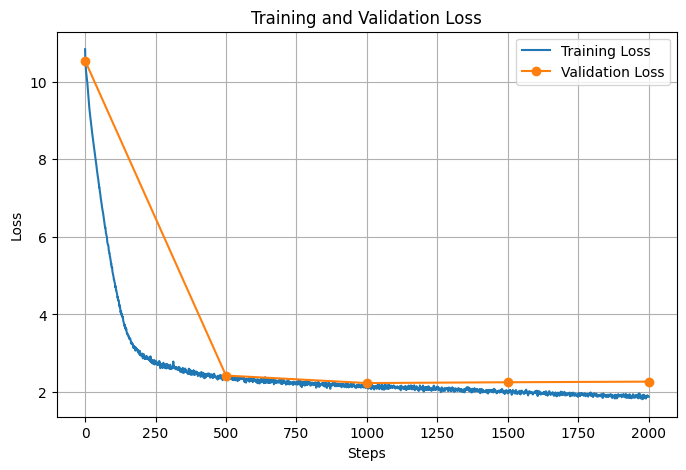

In [ ]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint = torch.load("small_gpt_v2.pt", map_location=device)

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss')
plt.plot(range(0, len(train_losses), 500), val_losses, label='Validation Loss', marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## Version 3 Lightning GPT
---
This is an improvement of the small-GPT crated before. Here are the changes we made to make the model better:
- Use pytorch lightning.
- Increase num_heads (4->8).
- Make training longer (max_iters 2000->3000).
- Add dropout (0.2).
- Update special character tokens (to singular characters).
- Improve the model and the generate function so it generates 3 lines each time and considers syllable count (used syllapy).

In [ ]:
!pip install tiktoken pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 53.5 MB/s eta 0:00:00


In [ ]:
!python gpt_v3.py

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2025-11-24 10:17:08.651673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763979428.671408    9093 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763979428.677577    9093 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763979428.692951    9093 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763979428.692982    9093 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 0

The model is trying to recognise the haiku patterns, but it has larger losses compared to the v2 small GPT. The text is more incoherent.

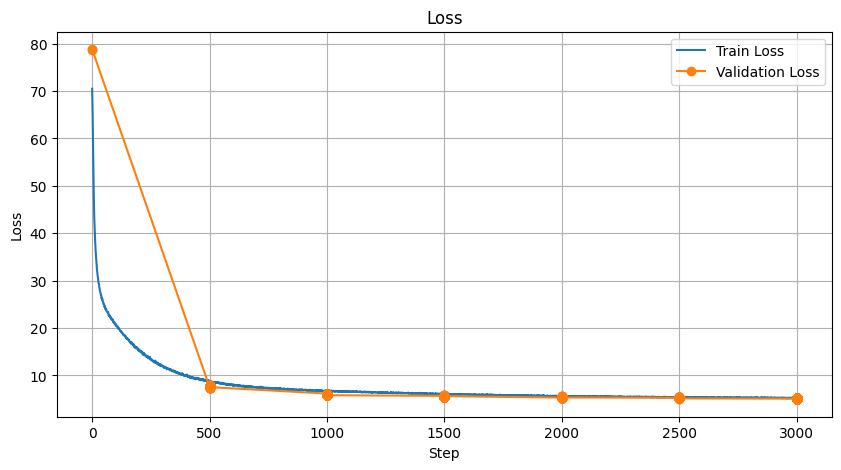

In [ ]:
import matplotlib.pyplot as plt
import csv

loss_history = []
with open("loss3_log.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        typ, step, loss = row
        loss_history.append((typ, int(step), float(loss)))

train_steps, train_losses = zip(*[(s, l) for t, s, l in loss_history if t=="train"])
val_steps, val_losses = zip(*[(s, l) for t, s, l in loss_history if t=="val"])

plt.figure(figsize=(10,5))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Version 4 Improved lightning GPT
---

This is an improvement for the v3-GPT crated before.

Here are the changes we made to make the model better:
- Tweak hyperparameters (Reduce dropout, num_heads, num_layers, block_size)
- Update the generate function slightly

In [ ]:
!python gpt_v4.py

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2025-11-24 10:31:26.892646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763980286.912635   12854 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763980286.918494   12854 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763980286.933628   12854 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763980286.933656   12854 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 0

This model managed to reduce loss more compared to v3.
We still fail to generate exactly 3 lines each time. The loss is still higher than the small GPT.

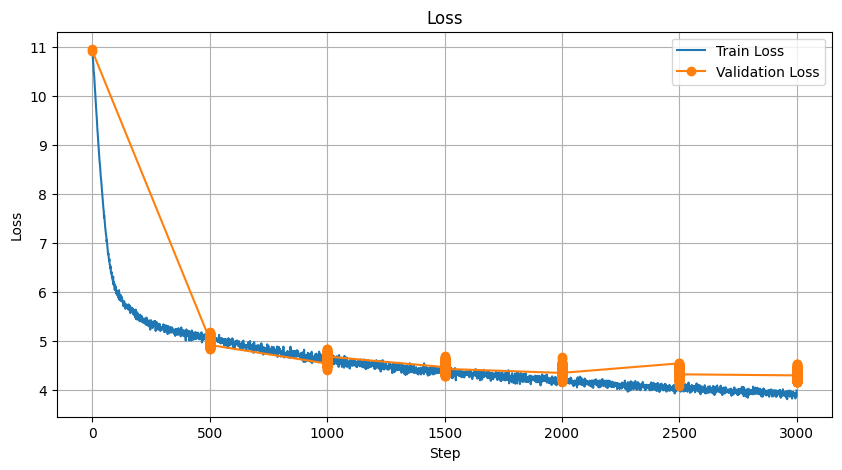

In [ ]:
import matplotlib.pyplot as plt
import csv

loss_history = []
with open("loss4_log.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        typ, step, loss = row
        loss_history.append((typ, int(step), float(loss)))

train_steps, train_losses = zip(*[(s, l) for t, s, l in loss_history if t=="train"])
val_steps, val_losses = zip(*[(s, l) for t, s, l in loss_history if t=="val"])

plt.figure(figsize=(10,5))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Version 5 Word-level GPT
---

- Switched to word-level tokenization.
- Updated hyperparameters.

In [ ]:
!python gpt_v5.py

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2025-11-26 15:33:25.777171: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764171205.799992    5323 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764171205.806562    5323 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764171205.823953    5323 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764171205.824004    5323 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 0

The model finally manages to produce 3-line haikus most of the time. The syllable counts are also right some of the time. But there's little logical meaning to the haikus. Also, the losses showcase that there could be some overfitting.

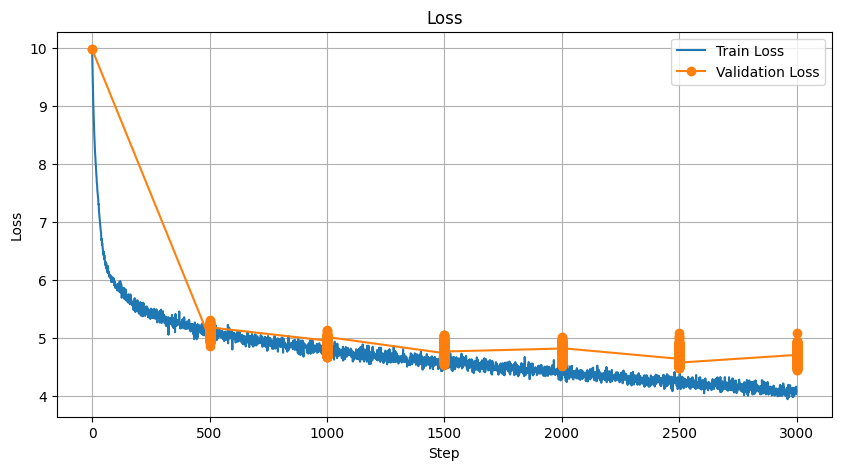

In [ ]:
import matplotlib.pyplot as plt
import csv

loss_history = []
with open("loss5_log.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        typ, step, loss = row
        loss_history.append((typ, int(step), float(loss)))

train_steps, train_losses = zip(*[(s, l) for t, s, l in loss_history if t=="train"])
val_steps, val_losses = zip(*[(s, l) for t, s, l in loss_history if t=="val"])

plt.figure(figsize=(10,5))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Version 6 Word-level GPT on bigger data
---
- Here we try to use bigger input data so we have more text to train on. This might improve the models ability to generate meaningful text.
- The rest of the model is the same as for version 5.

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
haiku_long = df['text'].dropna()
haiku_long = haiku_long.str.replace(" / ", "\n")
haiku_long = haiku_long.str.replace(r'[\[\]]', '', regex=True).str.strip()

In [ ]:
haiku_long = haiku_long.drop_duplicates()

In [ ]:
haiku_long.describe()

,text
count,40926
unique,40926
top,Alpine Lake.\nMybreaststrokesshiningarc.\nToward sunrise.
freq,1


In [ ]:
pd.set_option('display.max_colwidth', None)
haiku_long.sample(10)

,text
11603,My sister wives will.\nBe happily moistened so.\nI make sex at them.
28511,South Road.\nCrossings on a fence.\nWhere a family ended?
37519,Day Moon.\nThe clock has stopped.\nTicking
5842,A sword cannot cut.\nThe vows we have made or the.\nMemories we share.
22049,"They don't wanna see.\nUs together, I won't change.\nOn you for nothing."
8433,When you travel long?\nDistance to be with your babe.\nAnd you get distant.
13624,"Besides cry, listen.\nTo music that matches my.\nMood write a letter."
21691,Don't tell me nothing.\nThat's going on in the hood.\nI don't reside there.
30376,Downpour.\nTwo blackbirds bathing.\nIn cherry blossoms.
17054,It's crazy how a.\nTemorous disease can sneak up.\nOn the one you love.


In [ ]:
with open("haiku_long.txt", "w", encoding="utf-8") as f:
    f.write("\n\n".join(haiku_long))

In [ ]:
with open('haiku_long.txt', 'r', encoding='utf-8') as f:
  haiku = f.read()

In [ ]:
!python gpt_v6.py

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2025-11-26 15:40:47.539655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764171647.563410    7217 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764171647.570072    7217 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764171647.587391    7217 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764171647.587441    7217 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 0

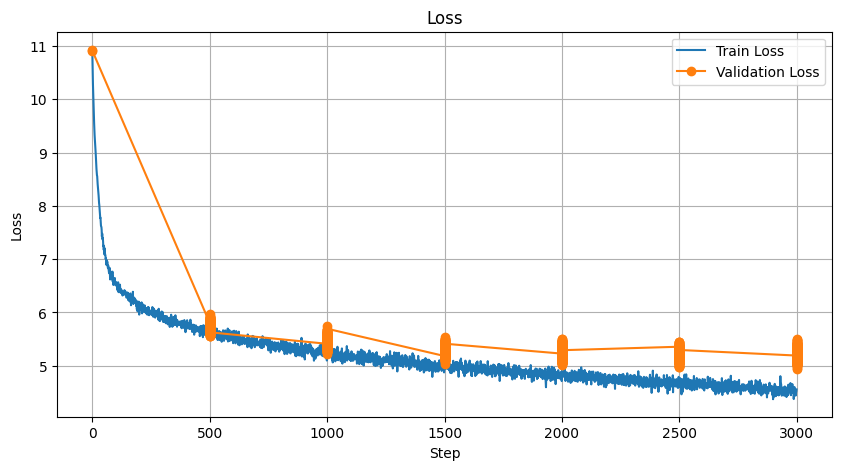

In [ ]:
import matplotlib.pyplot as plt
import csv

loss_history = []
with open("loss6_log.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        typ, step, loss = row
        loss_history.append((typ, int(step), float(loss)))

train_steps, train_losses = zip(*[(s, l) for t, s, l in loss_history if t=="train"])
val_steps, val_losses = zip(*[(s, l) for t, s, l in loss_history if t=="val"])

plt.figure(figsize=(10,5))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

Training on the bigger model did not improve the much (compared to version 5). Overall training and val losses are higher and there is some mild overfitting on training data.

## Version 7 Final GPT
Improvement for model 6:
- Trained for longer (5000 iters).
- Increased dropout.
- 0.1 weight decay.
- Updated generate function.


In [ ]:
!python gpt_v7.py

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
2025-11-26 16:51:16.233887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764175876.253113    5105 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764175876.259008    5105 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764175876.274066    5105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764175876.274094    5105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 0

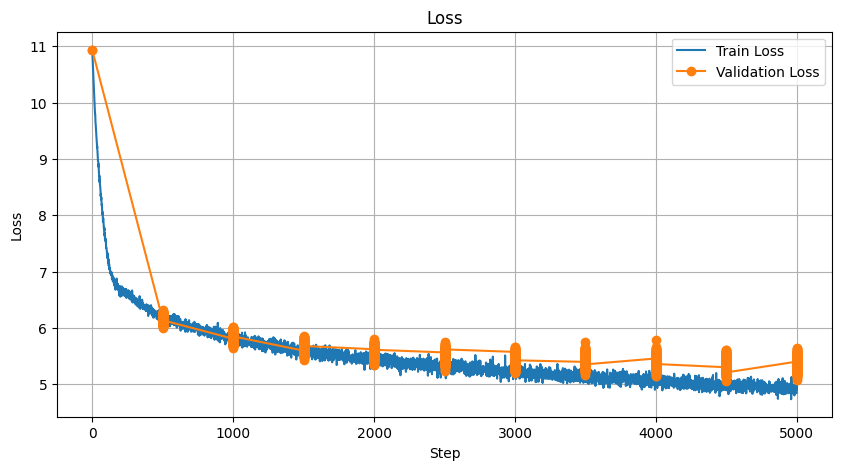

In [ ]:
import matplotlib.pyplot as plt
import csv

loss_history = []
with open("loss7_log.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        typ, step, loss = row
        loss_history.append((typ, int(step), float(loss)))

train_steps, train_losses = zip(*[(s, l) for t, s, l in loss_history if t=="train"])
val_steps, val_losses = zip(*[(s, l) for t, s, l in loss_history if t=="val"])

plt.figure(figsize=(10,5))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss", marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

We can see that the train and val losses are pretty much the same and even a bit worser. But we managed to control some of the overfitting. The text seems to be a bit more coherent, but following the haiku's syllable structure seems to still be a bit too hard.